import Libraries


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load train data

In [17]:
train_df = pd.read_csv('../data/raw/train.csv')
display(train_df.head())
print(f"Train data shape: {train_df.shape}")
train_df.info()
train_df.describe()
train_df.isnull().sum()

C:\Users\kztam\AppData\Local\Temp\ipykernel_28932\1695993492.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('../data/raw/train.csv')


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


Train data shape: (1017209, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 79.5+ MB


Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

Load store data

In [18]:
store_df = pd.read_csv('../data/raw/store.csv')
display(store_df.head())
print(f"Store data shape: {store_df.shape}")
store_df.info()
store_df.describe()
store_df.isnull().sum()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


Store data shape: (1115, 10)
<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 98.0 KB


Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

Convert Data to actual format

In [19]:
train_df['Date'] = pd.to_datetime(train_df['Date'])
print(train_df["Date"].dtype)

datetime64[us]


Understanding the time period

In [20]:
print("Start date:", train_df["Date"].min())
print("End date:", train_df["Date"].max())

print("Number of unique dates:",
      train_df["Date"].nunique())

print("Days difference:",
      (train_df["Date"].max() - train_df["Date"].min()).days)

Start date: 2013-01-01 00:00:00
End date: 2015-07-31 00:00:00
Number of unique dates: 942
Days difference: 941


Find some KPI's


In [34]:
print("Total Stores:", train_df['Store'].nunique())
print("Average daily sales per store:", train_df['Sales'].mean().round(2))
print("Average number of customers per store:", train_df['Customers'].mean().round(2))
print("Closed store percentage:", (train_df['Open'].value_counts(normalize=True) * 100).round(2))

print("Minimum Date:", train_df['Date'].min())
print("Maximum Date:", train_df['Date'].max())

Total Stores: 1115
Average daily sales per store: 5773.82
Average number of customers per store: 633.15
Closed store percentage: Open
1    83.01
0    16.99
Name: proportion, dtype: float64
Minimum Date: 2013-01-01 00:00:00
Maximum Date: 2015-07-31 00:00:00


Aggregate all store by date

<class 'pandas.DataFrame'>
Shape: (942, 2)
Daily Sales:


,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


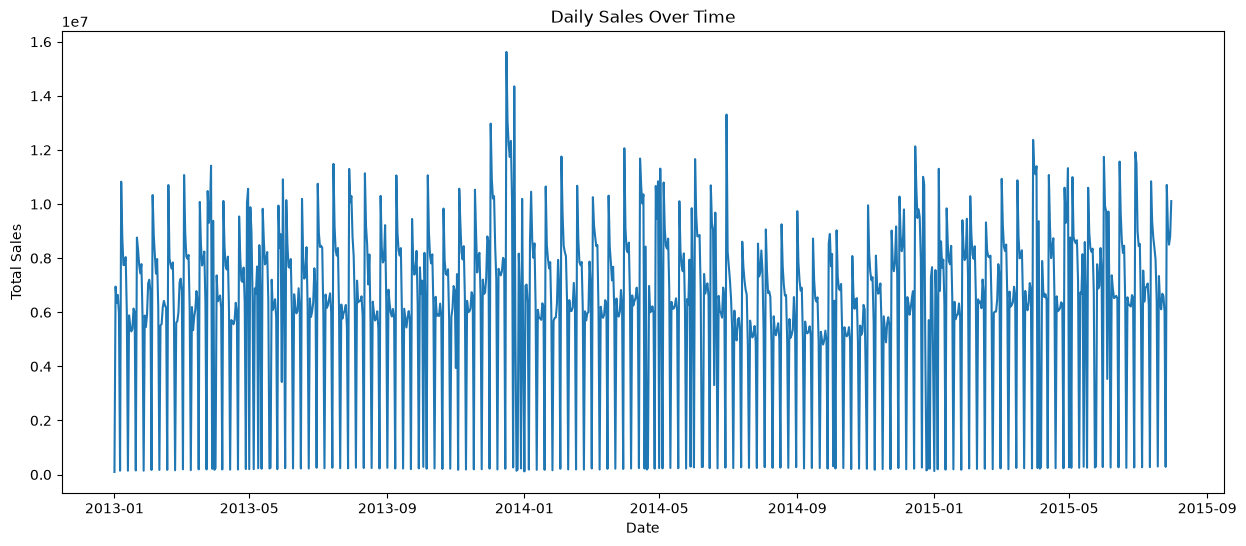

In [42]:
daily_sales = train_df.groupby('Date')['Sales'].sum().reset_index()
print(type(daily_sales))
print("Shape:", daily_sales.shape)
print("Daily Sales:")
display(daily_sales.head())

plt.figure(figsize=(15, 6))
plt.plot(daily_sales["Date"], daily_sales["Sales"])
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

investigate weekly behavior

Weekly Sales:


,DayOfWeek,Sales
0,Monday,7809.044510
1,Tuesday,7005.244467
2,Wednesday,6555.884138
3,Thursday,6247.575913
4,Friday,6723.274305
5,Saturday,5847.562599
6,Sunday,204.183189


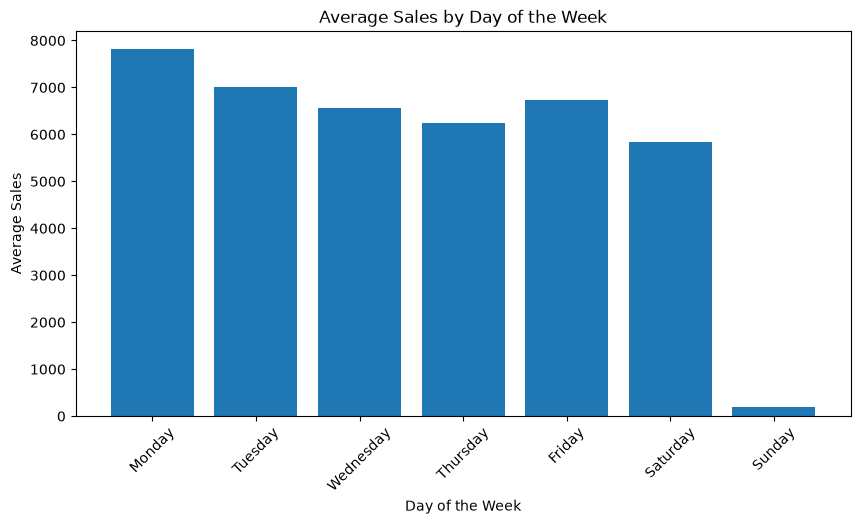

In [58]:
train_df["DayOfWeek"] = train_df["Date"].dt.day_name()

weekly_sales = train_df.groupby('DayOfWeek')['Sales'].mean().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']).reset_index()
print("Weekly Sales:"),
display(weekly_sales)


#Visualize the average sales by day of the week
plt.figure(figsize=(10, 5))
plt.bar(weekly_sales['DayOfWeek'], weekly_sales['Sales'])
plt.title('Average Sales by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.show()

investigate seasonality


Monthly Sales:


,Month,Sales
0,1,5465.40
1,2,5645.25
2,3,5784.58
3,4,5738.87
4,5,5489.64
5,6,5760.96
6,7,6064.92
7,8,5693.02
8,9,5570.25
9,10,5537.04


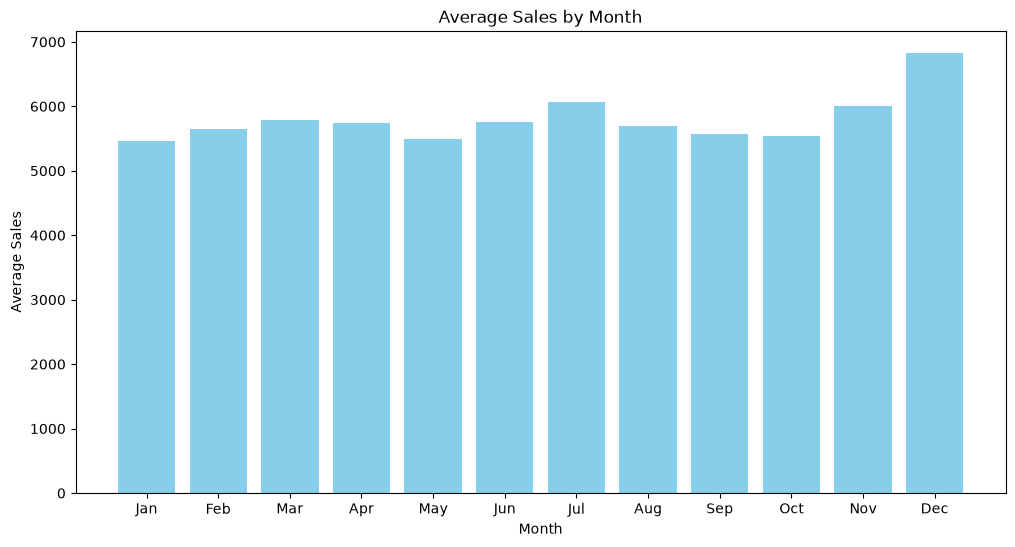

In [108]:
train_df["Month"] = train_df["Date"].dt.month
monthly_sales = train_df.groupby('Month')['Sales'].mean().reindex([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]).reset_index().round(2)
print("Monthly Sales:")
display(monthly_sales)

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(12, 6))
plt.bar(monthly_sales['Month'], monthly_sales['Sales'], color='skyblue')
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(monthly_sales['Month'], month_names)
plt.show()


In [103]:
highest_month = monthly_sales.loc[monthly_sales['Sales'].idxmax(), 'Month']
lowest_month = monthly_sales.loc[monthly_sales['Sales'].idxmin(), 'Month']

print("Highest sales month:", highest_month)
print("Lowest sales month:", lowest_month)

Highest sales month: 12
Lowest sales month: 1


Yearly investigate


Yearly Sales:


,Year,Month,Sales
0,2013,1,5211.555578
1,2013,2,5494.371397
2,2013,3,5820.349168
3,2013,4,5483.749836
4,2013,5,5364.127383
5,2013,6,5402.162960
6,2013,7,6042.062260
7,2013,8,5729.574049
8,2013,9,5322.988430
9,2013,10,5429.258788


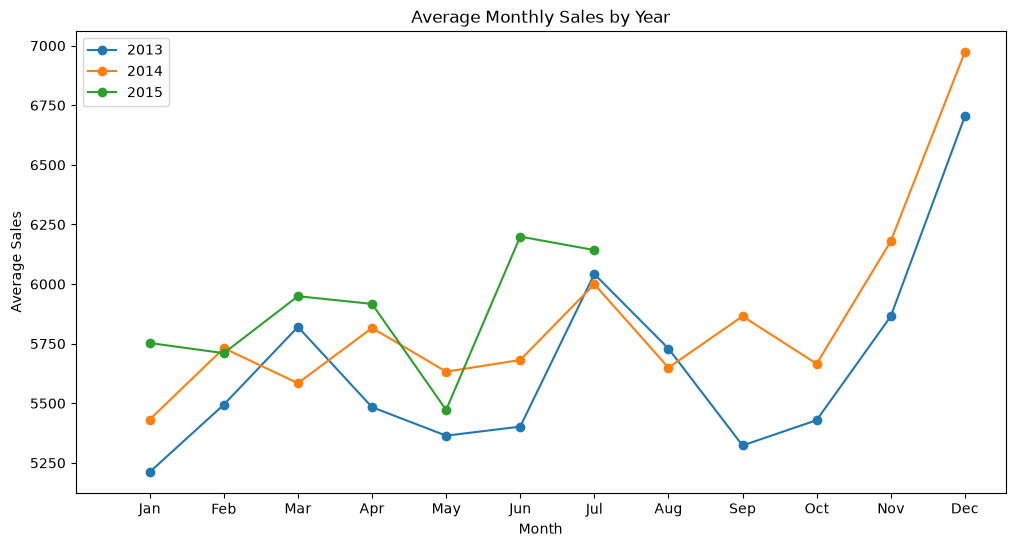

In [109]:
train_df['Year'] = train_df['Date'].dt.year
yearly_sales = train_df.groupby(['Year', 'Month'])['Sales'].mean().reset_index()

print("Yearly Sales:")
display(yearly_sales)


plt.figure(figsize=(12, 6))
for year in yearly_sales['Year'].unique():
    yearly_data = yearly_sales[yearly_sales['Year'] == year]

    plt.plot(yearly_data['Month'], yearly_data['Sales'], marker='o', label=str(year))

plt.xticks(range(12), month_names)

plt.title('Average Monthly Sales by Year')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(range(1,13), month_names)
plt.legend()
plt.show()
